# Target-Verteilung der MixUp-Variante

Dieses Notebook visualisiert die Target-Verteilung des standardmäßigen MixUp-Verfahrens.

Dieses Verfahren schneidet **zusammenhängende Slices** aus den Texten aus und mischt sie. Die Start- und End-Bereiche werden völlig unabhängig für Leichte Sprache (LS) und Alltagssprache (AS) gewählt.
Das Target wird über das Verhältnis der Zeichenanzahl des LS-Teils zur Gesamtzeichenanzahl des gemischten Absatzes berechnet.

In [10]:
import pandas as pd
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os

# Configuration
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
MIN_SIM = 0.8
MAX_SIM = 0.98

# Daten laden
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= MIN_SIM) & (df["semantic_similarity_8192"] <= MAX_SIM)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])
print(f"Gefundene Artikelpaare: {len(df_filtered)}")

# Spacy für schnelles Satz-Splitting (Sentencizer) vorbereiten
nlp = spacy.blank("de")
nlp.add_pipe("sentencizer")

Gefundene Artikelpaare: 1032


## 2. Dataset Klasse definieren

In [11]:
class MixupDataset(Dataset):
    def __init__(self, df, nlp_sentencizer):
        self.ls_data = []
        self.as_data = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere"):
            ls_sents = [s.text.strip() for s in nlp_sentencizer(str(row["ls_text"])).sents if s.text.strip()]
            as_sents = [s.text.strip() for s in nlp_sentencizer(str(row["as_text"])).sents if s.text.strip()]
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
    def __len__(self):
        return len(self.ls_data)
        
    def __getitem__(self, idx):
        leichte_saetze = self.ls_data[idx]
        alltags_saetze = self.as_data[idx]
        
        num_leicht = len(leichte_saetze)
        num_alltag = len(alltags_saetze)
        
        if num_leicht == 0 or num_alltag == 0:
            return "", 0.5
            
        start_leichte_saetze, ende_leichte_saetze = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
        sample_leicht = leichte_saetze[start_leichte_saetze:ende_leichte_saetze]
        
        start_alltags_saetze, ende_alltags_saetze = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
        sample_alltag = alltags_saetze[start_alltags_saetze:ende_alltags_saetze]
        
        kompletter_absatz = sample_leicht + sample_alltag
        random.shuffle(kompletter_absatz)
        
        str_sample_leicht = ''.join(sample_leicht)
        str_sample_alltag = ''.join(sample_alltag)
        len_sample_leicht = len(str_sample_leicht)
        len_sample_alltag = len(str_sample_alltag)
        
        total_len = len_sample_leicht + len_sample_alltag
        regression_target = len_sample_leicht / total_len if total_len > 0 else 0.5
        
        return ' '.join(kompletter_absatz), regression_target

mixup_ds = MixupDataset(df_filtered, nlp)

Segmentiere:   0%|          | 0/1032 [00:00<?, ?it/s]

## 3. Beispiel-Absatz ausgeben

In [12]:
print("="*80)
print("BEISPIEL EINES ZUSAMMENGESTELLTEN ABSATZES (MixupDataset)")
print("="*80)
found_example = False
for i in range(len(mixup_ds)):
    leichte_saetze = mixup_ds.ls_data[i]
    alltags_saetze = mixup_ds.as_data[i]
    if len(leichte_saetze) >= 5 and len(alltags_saetze) >= 5:
        start_l, end_l = sorted([random.randint(0, len(leichte_saetze)), random.randint(0, len(leichte_saetze))])
        sample_l = leichte_saetze[start_l:end_l]
        
        start_a, end_a = sorted([random.randint(0, len(alltags_saetze)), random.randint(0, len(alltags_saetze))])
        sample_a = alltags_saetze[start_a:end_a]
        
        if len(sample_l) > 0 and len(sample_a) > 0:
            labeled_sents = [(s, "LS") for s in sample_l] + [(s, "AS") for s in sample_a]
            random.shuffle(labeled_sents)
            
            shuffled_text = " ".join([s[0] for s in labeled_sents])
            len_l = len("".join(sample_l))
            len_a = len("".join(sample_a))
            total_len = len_l + len_a
            target = len_l / total_len if total_len > 0 else 0.5
            
            print(f"LS-Sätze (Extrakt, n={len(sample_l)}):")
            for s in sample_l:
                print(f"  - {s}")
            print(f"\nAS-Sätze (Extrakt, n={len(sample_a)}):")
            for s in sample_a:
                print(f"  - {s}")
            print(f"\nZusammengestellter Absatz:")
            print(f"  {shuffled_text}")
            print(f"\nSatz-Herkunft (Visualisiert):")
            vis = " ".join([f"[{tag}] {s}" for s, tag in labeled_sents])
            print(f"  {vis}")
            print(f"\nRegression Target (Zeichen-Verhältnis): {target:.4f}")
            print("="*80 + "\n")
            found_example = True
            break
if not found_example:
    print("Kein passendes Artikelpaar gefunden.")
    print("="*80 + "\n")

BEISPIEL EINES ZUSAMMENGESTELLTEN ABSATZES (MixupDataset)
LS-Sätze (Extrakt, n=2):
  - Inhaltsverzeichnis Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - Gesetzlicher Auftrag Politisch und sozial mitgestalten Informieren – Beraten – Öffentlichkeitsarbeit leisten – Inklusions-Gedanken verbreiten Grenzen der Beratung Video: Was macht der Behindertenbeauftragte der Bundesregierung?

AS-Sätze (Extrakt, n=3):
  - Das Amt des Beauftragten der Bundesregierung für die Belange von Menschen mit Behinderungen umfasst vielfältige Aufgaben.
  - Erfahren Sie hier mehr!
  - Inhaltsverzeichnis Video: Was macht der Behindertenbeauftragte der Bundesregierung?

Zusammengestellter Absatz:
  Das Amt des Beauftragten der Bundesregierung für die Belange von Menschen mit Behinderungen umfasst vielfältige Aufgaben. Inhaltsverzeichnis Video: Was macht der Behindertenbeauftragte der Bundesregierung? Gesetzlicher Auftrag Politisch und sozial mitgestalten Informieren – Beraten – Öffentlichkeit

## 4. Simulation & Target-Erfassung

In [13]:
targets = []

EPOCHS = 10
for epoch in range(EPOCHS):
    for i in range(len(df_filtered)):
        _, t = mixup_ds[i]
        targets.append(t)

print(f"Simulation beendet. {len(targets)} Samples generiert.")

Simulation beendet. 10320 Samples generiert.


## 5. Visualisierung der Target-Verteilung

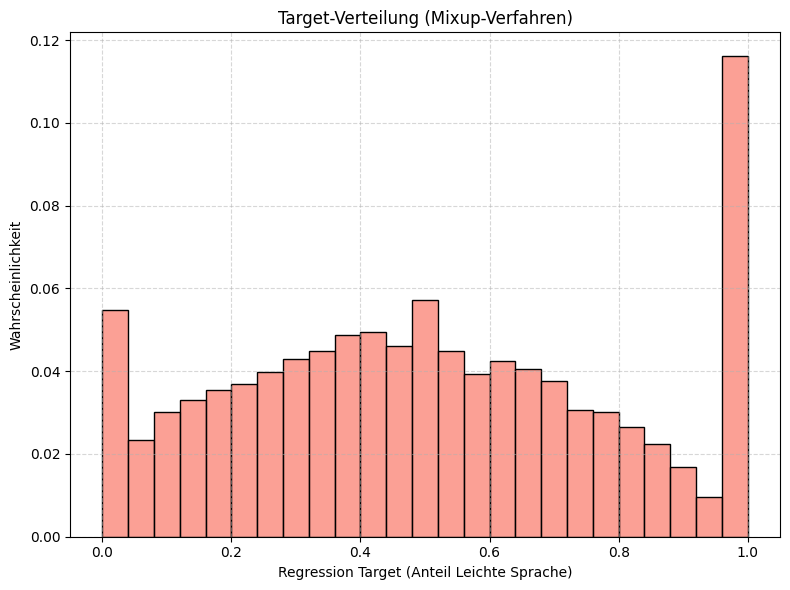

In [14]:
plt.figure(figsize=(8, 6))

sns.histplot(targets, bins=25, kde=False, color="salmon", stat="probability")
plt.title("Target-Verteilung (Mixup-Verfahren)")
plt.xlabel("Regression Target (Anteil Leichte Sprache)")
plt.ylabel("Wahrscheinlichkeit")
plt.xlim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Vorbereitung für das BiLSTM-Regressions-Training

Hier teilen wir die bereinigten Daten in Training (90%) und Validierung (10%) auf, erstellen das Vokabular auf Basis der Trainingsdaten und definieren eine angepasste `MixupPyTorchDataset`-Klasse für PyTorch.

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

# 1. Train-Val Split
train_df, val_df = train_test_split(df_filtered, test_size=0.1, random_state=42)
print(f"Training Artikelpaare: {len(train_df)}, Validierung Artikelpaare: {len(val_df)}")

# 2. Vokabular-Klasse definieren
class Vocab:
    def __init__(self, token_list, max_size=20000, min_freq=2):
        counter = Counter(token_list)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

# Vokabular aufbauen
print("Sammle Tokens für das Vokabular...")
all_train_tokens = []
# Wir nutzen denselben blanken Spacy-Tokenizer für Konsistenz
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Vokab-Tokens sammeln"):
    for text in [str(row["ls_text"]), str(row["as_text"])]:
        doc = nlp(text)
        for token in doc:
            if not token.is_space:
                all_train_tokens.append(token.text.lower())

vocab = Vocab(all_train_tokens, max_size=25000, min_freq=2)
print(f"Vokabular-Größe: {len(vocab)}")

# 3. PyTorch-kompatible Mixup-Dataset-Klasse (Deterministisch & Prä-generiert)
class MixupPyTorchDataset(Dataset):
    def __init__(self, df, vocab, nlp_sentencizer, max_seq_len=150, mixtures_per_pair=5, is_train=True):
        self.vocab = vocab
        self.max_seq_len = max_seq_len
        self.is_train = is_train
        self.current_epoch = 0
        self.total_epochs = 40
        
        self.ls_data = []
        self.as_data = []
        self.static_samples = []
        
        # Seed festlegen für Konsistenz und Reproduzierbarkeit der statischen Samples
        seed = 42 if is_train else 99
        random.seed(seed)
        
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere & Tokenisiere"):
            ls_doc = nlp_sentencizer(str(row["ls_text"]))
            as_doc = nlp_sentencizer(str(row["as_text"]))
            
            ls_sents = []
            for sent in ls_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    ls_sents.append((tokens, len(text)))
                    
            as_sents = []
            for sent in as_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    as_sents.append((tokens, len(text)))
                    
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            if num_leicht == 0 or num_alltag == 0:
                continue
                
            # Wir speichern die Sätze für dynamische Generierung on-the-fly
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
            # Prä-generiere feste Mischungen pro Artikelpaar
            article_idx = len(self.ls_data) - 1
            for _ in range(mixtures_per_pair):
                start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
                sample_l = ls_sents[start_l:end_l]
                
                start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
                sample_a = as_sents[start_a:end_a]
                
                if len(sample_l) == 0 and len(sample_a) == 0:
                    regression_target = 0.5
                    encoded = [0] * self.max_seq_len
                else:
                    char_len_l = sum(item[1] for item in sample_l)
                    char_len_a = sum(item[1] for item in sample_a)
                    total_char_len = char_len_l + char_len_a
                    regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                    
                    mixed_sentences = [item[0] for item in sample_l] + [item[0] for item in sample_a]
                    random.shuffle(mixed_sentences)
                    
                    flat_tokens = [token for sent in mixed_sentences for token in sent]
                    encoded = self.vocab.encode(flat_tokens)
                    
                    if len(encoded) > self.max_seq_len:
                        encoded = encoded[:self.max_seq_len]
                    else:
                        encoded = encoded + [0] * (self.max_seq_len - len(encoded))
                        
                self.static_samples.append((article_idx, encoded, regression_target))
                
        print(f"Generiert: {len(self.static_samples)} statische Samples.")
        
    def set_epoch(self, epoch, total_epochs):
        self.current_epoch = epoch
        self.total_epochs = total_epochs
            
    def __len__(self):
        return len(self.static_samples)
        
    def __getitem__(self, idx):
        article_idx, static_encoded, static_target = self.static_samples[idx]
        
        if not self.is_train:
            return torch.tensor(static_encoded, dtype=torch.long), torch.tensor(static_target, dtype=torch.float)
            
        p_dynamic = self.current_epoch / max(1, self.total_epochs - 1)
        
        if random.random() < p_dynamic:
            ls_sents = self.ls_data[article_idx]
            as_sents = self.as_data[article_idx]
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
            sample_l = ls_sents[start_l:end_l]
            
            start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
            sample_a = as_sents[start_a:end_a]
            
            if len(sample_l) == 0 and len(sample_a) == 0:
                encoded = [0] * self.max_seq_len
                regression_target = 0.5
            else:
                char_len_l = sum(item[1] for item in sample_l)
                char_len_a = sum(item[1] for item in sample_a)
                total_char_len = char_len_l + char_len_a
                regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                
                mixed_sentences = [item[0] for item in sample_l] + [item[0] for item in sample_a]
                random.shuffle(mixed_sentences)
                
                flat_tokens = [token for sent in mixed_sentences for token in sent]
                encoded = self.vocab.encode(flat_tokens)
                
                if len(encoded) > self.max_seq_len:
                    encoded = encoded[:self.max_seq_len]
                else:
                    encoded = encoded + [0] * (self.max_seq_len - len(encoded))
                    
            return torch.tensor(encoded, dtype=torch.long), torch.tensor(regression_target, dtype=torch.float)
        else:
            return torch.tensor(static_encoded, dtype=torch.long), torch.tensor(static_target, dtype=torch.float)

# Datasets instanziieren (Trainingsdaten augmentieren, Validierung deterministisch halten)
print("Erstelle PyTorch Datasets...")
train_dataset = MixupPyTorchDataset(train_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=10, is_train=True)
val_dataset = MixupPyTorchDataset(val_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=2, is_train=False)


Training Artikelpaare: 928, Validierung Artikelpaare: 104
Sammle Tokens für das Vokabular...


Vokab-Tokens sammeln:   0%|          | 0/928 [00:00<?, ?it/s]

Vokabular-Größe: 11006
Erstelle PyTorch Datasets...


Segmentiere & Tokenisiere:   0%|          | 0/928 [00:00<?, ?it/s]

Generiert: 9280 statische Samples.


Segmentiere & Tokenisiere:   0%|          | 0/104 [00:00<?, ?it/s]

Generiert: 208 statische Samples.


## 7. Modelldefinition (BiLSTM Regressor)

Wir definieren einen BiLSTM-Regressor zur Vorhersage von $\lambda$. Da $\lambda$ ein kontinuierlicher Wert zwischen 0 und 1 ist, verwenden wir am Ende ein lineares Layer mit einer anschließenden Sigmoid-Aktivierungsfunktion.

In [16]:
import torch.nn as nn

class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

## 8. Training des Regressionsmodells

Wir trainieren das Modell mit dem AdamW Optimizer und MSE-Loss (Mean Squared Error). Wir führen Early Stopping auf Basis des Validierungs-Loss ein.

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Hyperparameter
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 40
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Device: {DEVICE}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = BiLSTMRegressor(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.MSELoss()
# Zyklischer Scheduler definieren
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-5)


history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience = 5
counter = 0

# Verzeichnis für Ergebnisse erstellen falls nicht vorhanden
os.makedirs("../results", exist_ok=True)

for epoch in range(EPOCHS):
    # Dataset über aktuelle Epoche informieren
    train_dataset.set_epoch(epoch, EPOCHS)
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        preds = model(batch_x).squeeze()
        
        # Sicherstellen, dass die Dimensionen übereinstimmen
        if preds.ndim == 0:
            preds = preds.unsqueeze(0)
            
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    # Validation
    model.eval()
    val_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            preds = model(batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
                
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            
    epoch_train_loss = epoch_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_mae = mean_absolute_error(all_targets, all_preds)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_mae'].append(epoch_val_mae)
    
    print(f"Epoch {epoch+1:02d} | Train Loss (MSE): {epoch_train_loss:.4f} | Val Loss (MSE): {epoch_val_loss:.4f} | Val MAE: {epoch_val_mae:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "../results/bilstm_mixup_regression_hybrid_cyclic.pt")
        print("=> Modell gespeichert (bester Val Loss)")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping ausgelöst.")
            break

    # Lernrate anpassen und ausgeben
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Aktuelle Learning Rate: {current_lr:.6f}")


Nutze Device: cpu


Epoch 1:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 01 | Train Loss (MSE): 0.0771 | Val Loss (MSE): 0.0755 | Val MAE: 0.2190
=> Modell gespeichert (bester Val Loss)
Aktuelle Learning Rate: 0.000976


Epoch 2:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 02 | Train Loss (MSE): 0.0562 | Val Loss (MSE): 0.0705 | Val MAE: 0.2042
=> Modell gespeichert (bester Val Loss)
Aktuelle Learning Rate: 0.000905


...

Epoch 36 | Train Loss (MSE): 0.0109 | Val Loss (MSE): 0.0281 | Val MAE: 0.1039
Aktuelle Learning Rate: 0.000352


Epoch 37:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 37 | Train Loss (MSE): 0.0112 | Val Loss (MSE): 0.0279 | Val MAE: 0.1024
Aktuelle Learning Rate: 0.000214


Epoch 38:   0%|          | 0/145 [00:00<?, ?it/s]

Epoch 38 | Train Loss (MSE): 0.0104 | Val Loss (MSE): 0.0281 | Val MAE: 0.1020
Early Stopping ausgelöst.


## 9. Auswertung und Visualisierung des Trainingsverlaufs

Hier visualisieren wir den Trainingsverlauf des Regressionsmodells (MSE über die Epochen) und vergleichen die echten Targets mit den vorhergesagten Werten der Validierungsdaten.

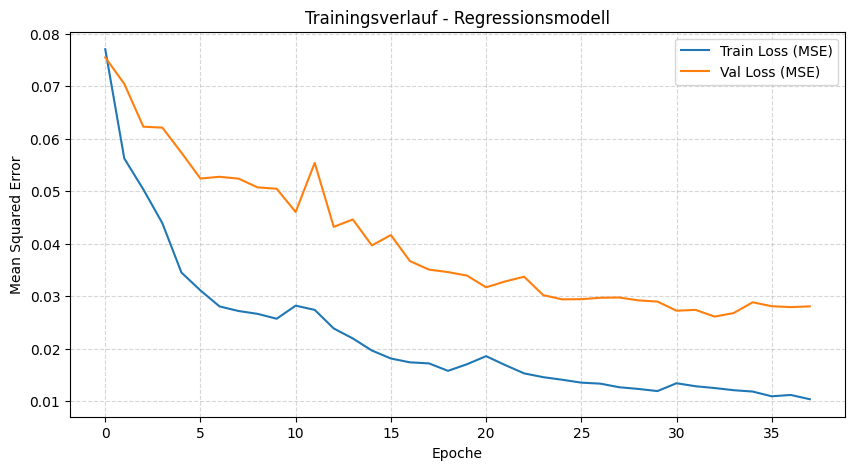

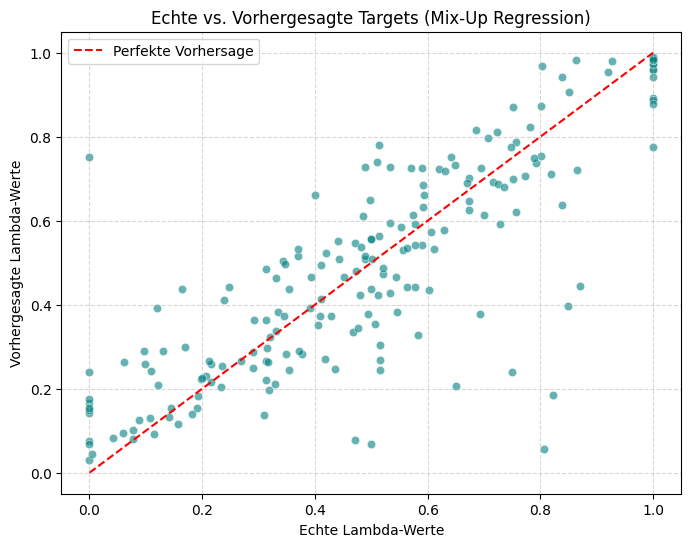

Abschließende Validierungsmetriken des besten Modells:
- Mean Squared Error (MSE): 0.0243
- Mean Absolute Error (MAE): 0.1025


In [18]:
# 1. Loss Plotten
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss (MSE)')
plt.plot(history['val_loss'], label='Val Loss (MSE)')
plt.title('Trainingsverlauf - Regressionsmodell')
plt.xlabel('Epoche')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2. Scatterplot: True vs Predicted
model.load_state_dict(torch.load("../results/bilstm_mixup_regression_hybrid_cyclic.pt"))
model.eval()
val_preds = []
val_targets = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(DEVICE)
        preds = model(batch_x).squeeze()
        if preds.ndim == 0:
            preds = preds.unsqueeze(0)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(batch_y.numpy())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=val_targets, y=val_preds, alpha=0.6, color="teal")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Perfekte Vorhersage")
plt.title("Echte vs. Vorhergesagte Targets (Mix-Up Regression)")
plt.xlabel("Echte Lambda-Werte")
plt.ylabel("Vorhergesagte Lambda-Werte")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Metriken ausgeben
val_mse = mean_squared_error(val_targets, val_preds)
val_mae = mean_absolute_error(val_targets, val_preds)
print(f"Abschließende Validierungsmetriken des besten Modells:")
print(f"- Mean Squared Error (MSE): {val_mse:.4f}")
print(f"- Mean Absolute Error (MAE): {val_mae:.4f}")